# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aliakhtar1010/search-ranking-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Which Web Pages Should Be Reviewed for a Content Refresh First?

### A machine-learning approach to content refresh prioritization using anonymized search-performance data

**Muhammad Ali Akhtar**  
Machine Learning Intern — FlyRank AI

---

## Abstract

Content teams may have thousands of existing webpages but limited time to decide which ones deserve review first. I studied whether search-performance and content signals could be used to rank webpages associated with a future-performance decline proxy more effectively than a simple hand-written refresh rule. The project combined an initial warehouse data contract with a 30,000-page anonymized modeling dataset, a transparent stale-and-visible baseline, Logistic Regression, Random Forest, client-grouped validation, and deliberate leakage tests. On the held-out client groups, Logistic Regression achieved Precision@20 of **0.75** and Precision@50 of **0.72**, compared with **0.20** and **0.30** for the frozen rule baseline on the same test population. The resulting system is intended as decision support for prioritizing human content review, not as evidence that refreshing a recommended page will cause search performance to improve.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

**Can a learned model rank webpages associated with a decline proxy more effectively near the top of a limited review queue than a simple stale-and-visible rule?**

The practical problem is not simply deciding whether a webpage is "good" or "bad." A content team may have far more existing pages than it can manually inspect, so the useful decision is:

> **Which pages should be reviewed first?**

I therefore frame the problem as **ranking/scoring**. Each page receives a priority score, and the highest-ranked pages are surfaced for human review.

The measurable target is a **decline proxy** based on the observed content trend label. Decline is not treated as proof that a page requires a refresh; it is a measurable signal used to identify pages that may deserve investigation.

The main evaluation metric is **Precision@K**, because the usefulness of the system depends most on the quality of the first 20–50 recommendations rather than on classifying every page correctly.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This project used two public-safe components of the FlyRank ML Internship data release.

### Warehouse data contract

The internship warehouse contains a large daily performance panel, including `fact_content_daily_performance`, whose grain is:

**report date × pseudonymized client × pseudonymized content item**

During the data-contract stage, I used a mid-panel March 2026 partition rather than the final-month sample. March contained **9,841,378 daily rows** spanning March 1–31, 2026, with **55 pseudonymized clients** and **331,437 content items**. I also inspected April 2026 as a later outcome period and kept the final month separate from development.

This warehouse work was used to verify grain, time-window logic, availability, and the difference between observed zero values and unavailable analytics data.

### Final modeling dataset

The Week-4 through Week-7 modeling pipeline used the fixed anonymized starter dataset:

- **30,000 webpages**
- **44 original columns**
- pseudonymized `content_id` and `client_id`
- 90-day search, analytics, content, and metadata signals

After constructing the evaluation label, the modeling frame contained 45 columns.

### Outcome

The binary proxy label was:

- `1` — `trend_direction == "down"`
- `0` — otherwise

The trend label is used only as the evaluation target. Fields directly used to construct or reveal that target are excluded from model inputs.

### Explicit exclusions

The final learned models exclude:

- `trend_direction`
- `trend_pct`
- `declining_label`
- direct last-30-day versus previous-30-day fields
- `client_id` and `content_id` as predictive inputs

IDs are used only for grouping, splitting, and reviewing results.

The final model therefore should be interpreted as a model of outcomes within this anonymized internship dataset, not as a universal model of Google Search.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "aliakhtar1010/search-ranking-ml/main/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

df["declining_label"] = (
    df["trend_direction"].str.lower() == "down"
).astype(int)

FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[FEATURES].copy()
y = df["declining_label"].copy()

print("Dataset rows:", len(df))
print("Features:", len(FEATURES))
print("Declining pages:", int(y.sum()))
print("Base decline rate:", round(float(y.mean()), 3))
print("Missing requested features:", [c for c in FEATURES if c not in df.columns])
print("scikit-learn:", sklearn.__version__)

Dataset rows: 30000
Features: 22
Declining pages: 16262
Base decline rate: 0.542
Missing requested features: []
scikit-learn: 1.6.1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Baseline

Before training a learned model, I created a transparent rule baseline.

A page qualifies for review when:

- `days_since_last_update >= 90`
- `impressions_90d >= 731`

Qualifying pages are ranked by `impressions_90d`.

The rule produces an interpretable `stale_but_visible` reason code and represents the simple heuristic that the learned model must beat.

### Learned models

I compared two supervised classifiers:

1. **Logistic Regression** — simple and interpretable.
2. **Random Forest** — a nonlinear ensemble capable of learning more complex feature interactions.

Because the real task is ranking rather than only yes/no classification, I use each classifier's predicted probability of the decline class as its ranking score.

### Validation design

The primary evaluation uses a **client-grouped holdout**.

Entire clients are assigned either to training or testing. Pages belonging to a test client therefore never appear in the training data.

With `random_state=42`, the split contains:

- **23,837 training pages from 25 clients**
- **6,163 test pages from 7 clients**
- **0 overlapping clients**

This is more conservative than randomly mixing pages because pages belonging to one client may share hidden characteristics.

### Leakage audit

The final feature set excludes target-derived fields, identifiers, and direct trend-window fields.

As a validation sanity check, I intentionally added `trend_pct`, which is directly related to the decline label. Precision@50 increased from **0.72 to 1.00**. I treated this as evidence of leakage rather than model improvement, removed the field, and retained the honest feature set.

### Evaluation

All methods are compared on the same held-out client population using:

- Precision@10
- Precision@20
- Precision@50
- test-set base rate

The random seed is fixed at `42` for reproducibility.

In [2]:
def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)
    return labels[order[:k]].mean()


# -------------------------
# Client-grouped split
# -------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=df["client_id"])
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

train_clients = set(train_df["client_id"])
test_clients = set(test_df["client_id"])

client_overlap = len(
    train_clients.intersection(test_clients)
)

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", client_overlap)
print("Test base rate:", round(float(y_test.mean()), 3))


# -------------------------
# Logistic Regression
# -------------------------

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)
logistic_scores = logistic_model.predict_proba(X_test)[:, 1]


# -------------------------
# Random Forest
# -------------------------

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_scores = rf_model.predict_proba(X_test)[:, 1]


# -------------------------
# Frozen baseline
# -------------------------

STALE_THRESHOLD = 90
VISIBILITY_THRESHOLD = 731

baseline_scores = np.where(
    (
        test_df["days_since_last_update"] >= STALE_THRESHOLD
    )
    &
    (
        test_df["impressions_90d"] >= VISIBILITY_THRESHOLD
    ),
    test_df["impressions_90d"],
    0
)

Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Client overlap: 0
Test base rate: 0.511


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results

### Learned ranking outperformed the fixed rule near the top of the held-out queue

Logistic Regression produced the strongest ranking on the client-grouped test set.

At **Precision@20 = 0.75**, 15 of the model's top 20 ranked pages belonged to the observed decline class. At **Precision@50 = 0.72**, 36 of the top 50 belonged to that class.

The Week-4 rule baseline reached only 0.20 at Precision@20 and 0.30 at Precision@50 on the same held-out pages.

Random Forest improved over the baseline at Precision@50 but remained weaker than Logistic Regression. This is a useful reminder that a more complex model is not automatically a better model.

The held-out decline base rate was approximately **0.51**, providing additional context for the ranking results.

In [3]:
base_rate = float(y_test.mean())

results_df = pd.DataFrame([
    {
        "Method": "Week-4 baseline",
        "Precision@10": precision_at_k(
            baseline_scores, y_test, 10
        ),
        "Precision@20": precision_at_k(
            baseline_scores, y_test, 20
        ),
        "Precision@50": precision_at_k(
            baseline_scores, y_test, 50
        )
    },
    {
        "Method": "Logistic Regression",
        "Precision@10": precision_at_k(
            logistic_scores, y_test, 10
        ),
        "Precision@20": precision_at_k(
            logistic_scores, y_test, 20
        ),
        "Precision@50": precision_at_k(
            logistic_scores, y_test, 50
        )
    },
    {
        "Method": "Random Forest",
        "Precision@10": precision_at_k(
            rf_scores, y_test, 10
        ),
        "Precision@20": precision_at_k(
            rf_scores, y_test, 20
        ),
        "Precision@50": precision_at_k(
            rf_scores, y_test, 50
        )
    }
])

results_df["Test base rate"] = base_rate

results_df

,Method,Precision@10,Precision@20,Precision@50,Test base rate
0,Week-4 baseline,0.3,0.20,0.30,0.510952
1,Logistic Regression,0.6,0.75,0.72,0.510952
2,Random Forest,0.5,0.50,0.56,0.510952


### Validation design changed the apparent result

As a sensitivity check, I also evaluated Logistic Regression with a random row split.

The random split produced Precision@50 of **0.82**, compared with **0.72** under the client-grouped split.

I retain the lower grouped result because it answers the harder question: whether the model can rank pages belonging to clients that were not represented during training. The difference between the two validation designs is itself evidence that evaluation design materially affects the headline number.

In [4]:
def make_logistic_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])


# Random row split
X_train_random, X_test_random, y_train_random, y_test_random = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

random_model = make_logistic_model()
random_model.fit(X_train_random, y_train_random)

random_scores = random_model.predict_proba(
    X_test_random
)[:, 1]

validation_df = pd.DataFrame([
    {
        "Validation design": "Random row split",
        "Base rate": y_test_random.mean(),
        "Precision@20": precision_at_k(
            random_scores, y_test_random, 20
        ),
        "Precision@50": precision_at_k(
            random_scores, y_test_random, 50
        )
    },
    {
        "Validation design": "Client-grouped split",
        "Base rate": y_test.mean(),
        "Precision@20": precision_at_k(
            logistic_scores, y_test, 20
        ),
        "Precision@50": precision_at_k(
            logistic_scores, y_test, 50
        )
    }
])

validation_df

,Validation design,Base rate,Precision@20,Precision@50
0,Random row split,0.542000,0.95,0.82
1,Client-grouped split,0.510952,0.75,0.72


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations and Honest Framing

This analysis supports a ranking decision, not a causal claim.

### Decline is a proxy

The label measures observed decline, not whether a webpage objectively requires refreshing. A page can decline for reasons unrelated to content quality, including seasonality, lower search demand, stronger competitors, SERP changes, or intentional changes in targeting.

### Refresh impact was not experimentally measured

The analysis did not randomly assign pages to refreshed and unrefreshed groups. It therefore cannot establish that refreshing a recommended page will increase impressions, clicks, rankings, or traffic.

### Modeling used the 30,000-page starter slice

The internship warehouse contains a much larger daily panel and was used for the earlier data-contract and temporal reasoning stages. However, the final Week-4 through Week-7 baseline and learned-model comparison used the fixed 30,000-page anonymized modeling dataset. I therefore do not claim that the final model was trained on the full warehouse.

### Validation is stronger, but still limited

The primary split holds out entire clients, which reduces the risk of learning client-specific patterns. It is still one grouped holdout split rather than repeated GroupKFold or a fully prospective deployment test.

### Feature dependence

Several traffic and engagement variables are correlated. Logistic Regression coefficients therefore describe model behavior conditional on the other inputs and should not be interpreted as independent causal effects.

### Human review remains necessary

High model probability is not certainty. Earlier error analysis found both high-confidence false positives and high-confidence false negatives. Recommendations should therefore support editorial and SEO review rather than trigger automatic content changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The final system converts model probabilities into a ranked human-review queue.

Four reason-code archetypes make the ranking easier to interpret:

### 1. `stale_visible_decline_risk` — Review for refresh

These pages combine:

- high predicted decline risk;
- meaningful existing search visibility;
- at least 90 days since the last update.

**Recommended action:** inspect content accuracy, missing coverage, dated evidence, intent alignment, and competition before deciding whether a refresh is justified.

### 2. `recent_visible_decline_risk` — Investigate decline

These pages have high modeled decline risk and meaningful visibility but were updated relatively recently.

**Recommended action:** investigate demand, rankings, competitors, search intent, cannibalization, or technical changes rather than assuming another refresh is needed.

### 3. `low_visibility_decline_risk` — Review if strategically important

These pages have high modeled decline risk but relatively little current visibility.

**Recommended action:** consider business importance and expected value before spending editorial resources.

### 4. `monitor`

Lower-risk pages remain in the queue but do not receive an immediate intervention recommendation.

### Human-review principle

The workflow is:

**model ranks → human investigates → human decides → outcome is monitored**

The model should not automatically rewrite, delete, redirect, merge, or republish content.

In [5]:
HIGH_RISK_THRESHOLD = 0.70

queue = test_df[
    [
        "content_id",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "days_since_last_update",
        "content_age_days",
        "word_count",
        "declining_label"
    ]
].copy()

queue["decline_probability"] = logistic_scores

queue["is_visible"] = (
    queue["impressions_90d"] >= VISIBILITY_THRESHOLD
)

queue["is_stale"] = (
    queue["days_since_last_update"] >= STALE_THRESHOLD
)

queue["high_decline_risk"] = (
    queue["decline_probability"] >= HIGH_RISK_THRESHOLD
)


def assign_reason(row):
    if (
        row["high_decline_risk"]
        and row["is_visible"]
        and row["is_stale"]
    ):
        return "stale_visible_decline_risk"

    if (
        row["high_decline_risk"]
        and row["is_visible"]
        and not row["is_stale"]
    ):
        return "recent_visible_decline_risk"

    if row["high_decline_risk"] and not row["is_visible"]:
        return "low_visibility_decline_risk"

    return "monitor"


ACTION_MAP = {
    "stale_visible_decline_risk": "review_for_refresh",
    "recent_visible_decline_risk": "investigate_decline",
    "low_visibility_decline_risk": "review_if_strategic",
    "monitor": "monitor"
}

queue["reason_code"] = queue.apply(
    assign_reason,
    axis=1
)

queue["action_label"] = (
    queue["reason_code"].map(ACTION_MAP)
)

queue["action_score"] = queue["decline_probability"]

queue = queue.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

print(queue["reason_code"].value_counts())

display(
    queue[
        [
            "rank",
            "content_id",
            "action_score",
            "impressions_90d",
            "days_since_last_update",
            "reason_code",
            "action_label"
        ]
    ].head(20)
)

reason_code
monitor                        5345
recent_visible_decline_risk     415
low_visibility_decline_risk     301
stale_visible_decline_risk      102
Name: count, dtype: int64


,rank,content_id,action_score,impressions_90d,days_since_last_update,reason_code,action_label
0,1,content_b08562686d22,0.890543,2846,106,stale_visible_decline_risk,review_for_refresh
1,2,content_8ede62882d0b,0.884867,556,20,low_visibility_decline_risk,review_if_strategic
2,3,content_453722754fea,0.876679,140079,20,recent_visible_decline_risk,investigate_decline
3,4,content_374e795aab68,0.866905,235,20,low_visibility_decline_risk,review_if_strategic
4,5,content_c94a53e3bfb8,0.865646,2164,20,recent_visible_decline_risk,investigate_decline
5,6,content_26d48a980581,0.864896,1266,106,stale_visible_decline_risk,review_for_refresh
6,7,content_a928cb66d230,0.862645,128,20,low_visibility_decline_risk,review_if_strategic
7,8,content_87c007fb5c26,0.859521,2463,20,recent_visible_decline_risk,investigate_decline
8,9,content_b51992d6cbc2,0.858300,1578,20,recent_visible_decline_risk,investigate_decline
9,10,content_c84a0ab98e90,0.858024,223271,20,recent_visible_decline_risk,investigate_decline


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

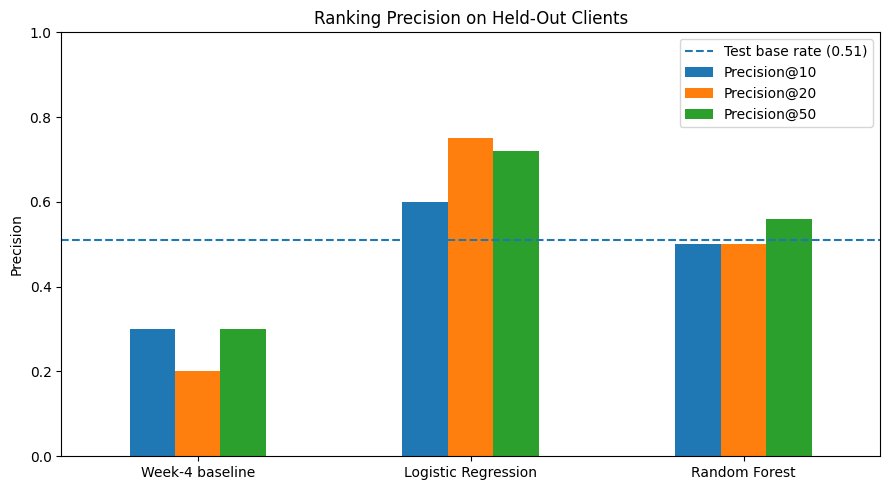

Saved: work/figures/model_precision_comparison.png


In [6]:
os.makedirs("work/figures", exist_ok=True)

plot_df = results_df.set_index("Method")[
    ["Precision@10", "Precision@20", "Precision@50"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.axhline(
    base_rate,
    linestyle="--",
    label=f"Test base rate ({base_rate:.2f})"
)

ax.set_title("Ranking Precision on Held-Out Clients")
ax.set_xlabel("")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend()

plt.tight_layout()

MODEL_FIGURE = "work/figures/model_precision_comparison.png"

plt.savefig(
    MODEL_FIGURE,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", MODEL_FIGURE)

**Figure takeaway:** Logistic Regression produced the strongest ranking near the top of the held-out client queue, while the more complex Random Forest did not outperform it.

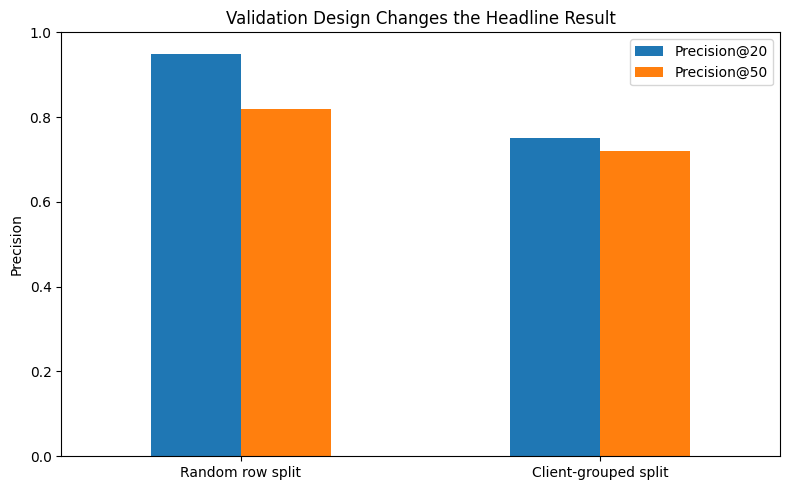

Saved: work/figures/validation_split_comparison.png


In [7]:
validation_plot = validation_df.set_index(
    "Validation design"
)[
    ["Precision@20", "Precision@50"]
]

ax = validation_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Validation Design Changes the Headline Result")
ax.set_xlabel("")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

VALIDATION_FIGURE = (
    "work/figures/validation_split_comparison.png"
)

plt.savefig(
    VALIDATION_FIGURE,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", VALIDATION_FIGURE)

**Figure takeaway:** Random row splitting produced a more optimistic result; the lower client-grouped score is retained because test clients were entirely unseen during training.

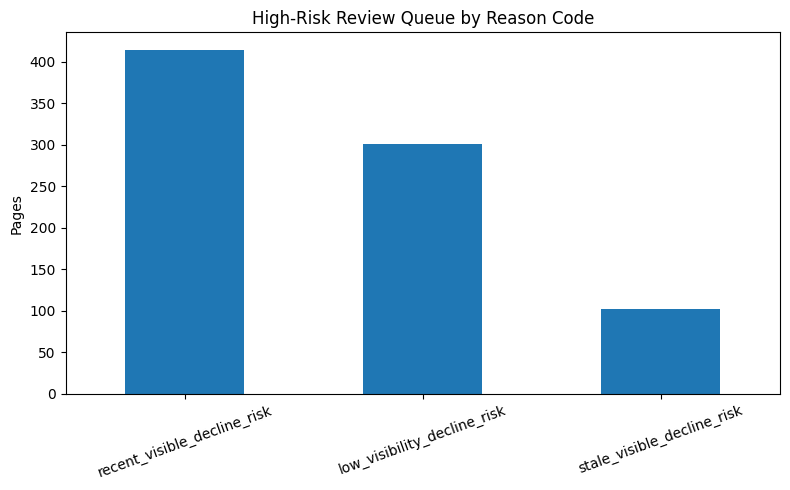

Saved: work/figures/action_reason_codes.png


In [8]:
action_counts = (
    queue["reason_code"]
    .value_counts()
    .drop("monitor", errors="ignore")
)

ax = action_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("High-Risk Review Queue by Reason Code")
ax.set_xlabel("")
ax.set_ylabel("Pages")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()

ACTION_FIGURE = (
    "work/figures/action_reason_codes.png"
)

plt.savefig(
    ACTION_FIGURE,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ACTION_FIGURE)

**Figure takeaway:** Most high-risk pages are not simply stale; the playbook separates recent visible declines, stale visible pages, and low-visibility cases into different review actions.

## Reproducibility

The analysis is contained in the public GitHub repository:

**Repository:**  
https://github.com/aliakhtar1010/search-ranking-ml

Key notebooks:

- `work/notebooks/w03_data_contract.ipynb` — warehouse contract and leakage lesson
- `work/notebooks/w04_baseline_score.ipynb` — transparent baseline
- `work/notebooks/w05_model.ipynb` — learned models
- `work/notebooks/w06_validation_audit.ipynb` — grouped validation and leakage audit
- `work/notebooks/w07_action_playbook.ipynb` — ranked action queue
- `work/notebooks/capstone.ipynb` — final reproducible analysis

The modeling pipeline uses `random_state=42`. The capstone records the feature set, grouped train/test design, baseline thresholds, model parameters, and evaluation metrics needed to reproduce the reported result.

The ranked queue CSV is regenerated by the notebook and excluded from Git by the repository's data guard. Metrics receipts and reusable figures remain in the repository.

In [9]:
os.makedirs("work/outputs", exist_ok=True)

metrics = {
    "random_state": RANDOM_STATE,
    "modeling_rows": int(len(df)),
    "features": int(len(FEATURES)),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_clients": int(len(train_clients)),
    "test_clients": int(len(test_clients)),
    "client_overlap": int(client_overlap),
    "test_base_rate": float(base_rate),

    "baseline_precision_at_20": float(
        precision_at_k(baseline_scores, y_test, 20)
    ),
    "baseline_precision_at_50": float(
        precision_at_k(baseline_scores, y_test, 50)
    ),

    "logistic_precision_at_20": float(
        precision_at_k(logistic_scores, y_test, 20)
    ),
    "logistic_precision_at_50": float(
        precision_at_k(logistic_scores, y_test, 50)
    ),

    "random_forest_precision_at_20": float(
        precision_at_k(rf_scores, y_test, 20)
    ),
    "random_forest_precision_at_50": float(
        precision_at_k(rf_scores, y_test, 50)
    ),

    "random_split_logistic_precision_at_50": float(
        precision_at_k(
            random_scores,
            y_test_random,
            50
        )
    ),

    "high_risk_pages": int(
        queue["high_decline_risk"].sum()
    ),

    "stale_visible_decline_risk": int(
        (
            queue["reason_code"]
            == "stale_visible_decline_risk"
        ).sum()
    ),

    "recent_visible_decline_risk": int(
        (
            queue["reason_code"]
            == "recent_visible_decline_risk"
        ).sum()
    ),

    "low_visibility_decline_risk": int(
        (
            queue["reason_code"]
            == "low_visibility_decline_risk"
        ).sum()
    )
}

with open(
    "work/outputs/capstone_metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=2)

queue[
    [
        "rank",
        "content_id",
        "action_score",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "days_since_last_update",
        "content_age_days",
        "reason_code",
        "action_label"
    ]
].to_csv(
    "work/outputs/capstone_ranked_queue.csv",
    index=False
)

print(json.dumps(metrics, indent=2))

{
  "random_state": 42,
  "modeling_rows": 30000,
  "features": 22,
  "train_rows": 23837,
  "test_rows": 6163,
  "train_clients": 25,
  "test_clients": 7,
  "client_overlap": 0,
  "test_base_rate": 0.5109524582184002,
  "baseline_precision_at_20": 0.2,
  "baseline_precision_at_50": 0.3,
  "logistic_precision_at_20": 0.75,
  "logistic_precision_at_50": 0.72,
  "random_forest_precision_at_20": 0.5,
  "random_forest_precision_at_50": 0.56,
  "random_split_logistic_precision_at_50": 0.82,
  "high_risk_pages": 818,
  "stale_visible_decline_risk": 102,
  "recent_visible_decline_risk": 415,
  "low_visibility_decline_risk": 301
}


## Acknowledgments & Data Credit

This project was completed as part of the FlyRank AI Machine Learning Internship.

**Built on the [FlyRank ML Internship dataset](https://flyrank.ai).**

The analysis uses anonymized and pseudonymized internship data. No client names, raw client URLs, private search queries, access tokens, or other identifying client information are included in this public artifact.

# Demo and Shareable Cuts

## 5-Minute Demo Outline

### 0:00–0:45 — The problem

FlyRank works with large existing content portfolios. The practical question I explored was not simply whether a page was declining, but which pages a content team should inspect first when review capacity is limited.

### 0:45–1:30 — The baseline

I started with a transparent rule: prioritize pages that had not been updated for at least 90 days and still had meaningful search visibility. This created an understandable benchmark that the machine-learning model had to beat.

### 1:30–2:30 — The model

I trained Logistic Regression and Random Forest models using 22 anonymized search, content, traffic, and engagement features. Predicted decline probabilities became ranking scores.

Rather than randomly mixing webpages, I held out entire clients. The final test set contained 6,163 pages from seven clients that were never represented during training.

### 2:30–3:30 — The result

**Chart:** Model-vs-baseline Precision@K comparison.

Logistic Regression achieved Precision@20 of 0.75 and Precision@50 of 0.72. The rule baseline achieved 0.20 and 0.30 on the same held-out pages.

A random row split produced a higher Precision@50 of 0.82, so I retained the lower grouped result as the more credible estimate.

### 3:30–4:20 — The honesty check

I deliberately added `trend_pct`, a feature related directly to the decline label. Precision@50 jumped to 1.00.

That was not a breakthrough — it was leakage. I removed the feature and kept the honest 0.72 grouped result.

### 4:20–5:00 — The recommendation

The final model does not automatically refresh content.

It creates a ranked human-review queue with reason codes:

- stale + visible + high risk → review for refresh
- recent + visible + high risk → investigate decline
- low visibility + high risk → review if strategically valuable

The model is decision support, not proof that refreshing a page will increase traffic.


## Social Post

I spent part of my ML internship working on a question that sounds simple but gets messy fast: **with thousands of existing webpages, which ones should a content team review first?**

I built a transparent rule baseline, trained Logistic Regression and Random Forest ranking models, and then tried to break my own result with client-grouped validation and deliberate leakage tests.

The most useful lesson wasn't that the more complex model won — it didn't. Logistic Regression reached **75% Precision@20 and 72% Precision@50** on held-out clients, while the Random Forest was weaker. A deliberately leaked feature pushed the result to 100%, which was a good reminder that suspiciously perfect ML usually deserves investigation, not celebration.

The final output is a ranked content-review queue with human-readable reason codes rather than an automatic refresh system.


## Employer-Facing Summary

Built an end-to-end machine-learning pipeline for ranking content refresh-review candidates using anonymized FlyRank search-performance data, including data contracts, a transparent rule baseline, Logistic Regression, Random Forest, grouped validation, leakage audits, and an interpretable action queue.

On a client-grouped holdout of **6,163 webpages from seven unseen clients**, Logistic Regression achieved **0.75 Precision@20 and 0.72 Precision@50**, compared with **0.20 and 0.30** for the frozen rule baseline on the same test population.

Converted model probabilities into human-reviewed reason codes and recommendations while explicitly auditing leakage, validation bias, and causal overclaiming.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
